# MVP Model

In [77]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [78]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
ML_PATH = "../../data/models/ml"
DL_PATH = "../../data/models/dl"
os.makedirs(ML_PATH, exist_ok=True)
os.makedirs(DL_PATH, exist_ok=True)

In [79]:
# Loading the cleaned player data set
player_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [80]:
# Loading the mvp data set
mvp_df = pd.read_csv(f"{PROCESSED_PATH}/mvp_eda_cleaned.csv")

In [81]:
# Removing unnamed column
mvp_df.drop(columns=["Unnamed: 0"], inplace=True)

In [82]:
# Creating a dataframe to hold the Season column before merging 
selected_features = list(mvp_df.drop(columns=["is_MVP"]).columns)
reduced_with_season = player_df[selected_features + ["Season", "is_MVP"]].dropna()

After reviewing the data, we see there are 2 missing values in three separate columns. However the missing values in each column represents less than 1% of the data. Since neither column is the target column "is_MVP" we're going to drop them.

In [83]:
# Dropping missing data
mvp_df.dropna(inplace=True)

In [84]:
# Checking to see if indexes match before merging
mvp_df.index.equals(reduced_with_season.index)

True

In [85]:
# Merging processed dataset with modified dataset to retain Season column
mvp_df["Season"] = reduced_with_season["Season"]

In [86]:
mvp_df.head(5)

,VORP,FT,TOV,AST,DRB,PER,AST%,USG%,is_MVP,Season
0,7.5,9.2,3.3,2.8,6.3,26.2,13.5,32.0,0,2010
1,10.3,7.8,3.4,8.6,6.4,31.1,41.8,33.5,1,2010
2,2.9,7.4,3.0,3.2,4.4,22.2,15.9,33.4,0,2010
3,4.4,6.0,3.2,5.0,4.3,21.9,23.8,32.3,0,2010
4,7.9,6.9,3.3,6.5,3.5,28.0,36.4,34.9,0,2010


In [87]:
# Checking to make sure no null values remain
print(mvp_df.isnull().sum())

VORP      0
FT        0
TOV       0
AST       0
DRB       0
PER       0
AST%      0
USG%      0
is_MVP    0
Season    0
dtype: int64


In [88]:
# Assigning everything in one go to save memory and compute time
X_train, X_test, y_train, y_test = train_test_split(mvp_df.drop(columns=["is_MVP"]), mvp_df["is_MVP"], test_size=0.2, random_state=42)

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [91]:
# Model results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1933    8]
 [   0    2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1941
           1       0.20      1.00      0.33         2

    accuracy                           1.00      1943
   macro avg       0.60      1.00      0.67      1943
weighted avg       1.00      1.00      1.00      1943



The initial model results shows us that the recall for MVPs = 1.0. This means all true MVPs are being captured. However, 8 non-MVPs were classified as MVPs using these methods. All non-MVPs were correctly predicted also.

## New approach : Handling data imbalance 
There is only 1 MVP in any given NBA season. We currently have 15 seasons worth of data, meaning amongst the 1000s of rows of data existing in this data set, only 15 rows will contain an MVP winner. So, to account for this we will change the approach and have the model try to find the MVP for a given season, separating the parameters on a per season basis.

In [92]:
mvp_normalized = mvp_df.copy()
features = mvp_normalized.drop(columns=["is_MVP", "Season"]).columns

for season in mvp_df["Season"].unique():
    season_mask = mvp_df["Season"] == season
    scaler = MinMaxScaler()
    mvp_normalized.loc[season_mask, features] = scaler.fit_transform(mvp_df.loc[season_mask, features])

In [93]:
# Assigning everything in one go to save memory and compute time
X_train, X_test, y_train, y_test = train_test_split(mvp_df.drop(columns=["is_MVP", "Season"]), mvp_df["is_MVP"], test_size=0.2, random_state=42)

In [94]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\bartl\Desktop\General-Projects\nba_awards_predictions\nba_env\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [95]:
# Creating a MVP Score column using the model 
X = mvp_normalized.drop(columns=["is_MVP", "Season"])
mvp_normalized["MVP_Score"] = model.predict_proba(X)[:,1]

In [96]:
predicted_mvps = mvp_normalized.loc[mvp_normalized.groupby("Season")["MVP_Score"].idxmax()]

In [97]:
# Evaluations
actual_mvps = mvp_normalized[mvp_normalized["is_MVP"] ==1]
correct_predictions = (predicted_mvps["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions} / {actual_mvps.shape[0]}")

Correct MVP predictions: 9 / 15


## Next we're going to test other models like Random Forest Classifier and XGBoost

In [98]:
# Random Forest 
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
mvp_normalized_rf = mvp_normalized.copy()

In [100]:
mvp_normalized_rf.drop(columns=["MVP_Score"], inplace=True)

In [101]:
# Creating a MVP Score column using the model 
X_rf = mvp_normalized_rf.drop(columns=["is_MVP", "Season"])
mvp_normalized_rf["MVP_Score"] = rf.predict_proba(X_rf)[:,1]

In [102]:
predicted_mvps_rf = mvp_normalized_rf.loc[mvp_normalized_rf.groupby("Season")["MVP_Score"].idxmax()]

In [103]:
# Evaluations
actual_mvps_rf = mvp_normalized_rf[mvp_normalized_rf["is_MVP"] ==1]
correct_predictions_rf = (predicted_mvps_rf["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions_rf} / {actual_mvps_rf.shape[0]}")

Correct MVP predictions: 5 / 15


In [104]:
# XGBoost
xgb = XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [105]:
mvp_normalized_xgb = mvp_normalized.copy()

In [106]:
mvp_normalized_xgb.drop(columns=["MVP_Score"], inplace=True)

In [107]:
# Creating a MVP Score column using the model 
X_xgb = mvp_normalized_xgb.drop(columns=["is_MVP", "Season"])
mvp_normalized_xgb["MVP_Score"] = xgb.predict_proba(X_xgb)[:,1]

In [108]:
predicted_mvps_xgb = mvp_normalized_xgb.loc[mvp_normalized_xgb.groupby("Season")["MVP_Score"].idxmax()]

In [109]:
# Evaluations
actual_mvps_xgb = mvp_normalized_xgb[mvp_normalized_xgb["is_MVP"] ==1]
correct_predictions_xgb = (predicted_mvps_xgb["is_MVP"] ==1).sum()

print(f"Correct MVP predictions: {correct_predictions_xgb} / {actual_mvps_xgb.shape[0]}")

Correct MVP predictions: 5 / 15


## Next phase: Deep Learning

In [110]:
features = mvp_df.drop(columns=["is_MVP", "Season"])
target = mvp_df["is_MVP"]

In [111]:
# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [112]:
# Convert to tensors
X_tensor = torch.tensor(features_scaled, dtype=torch.float32)
y_tensor = torch.tensor(target.values, dtype=torch.float32).unsqueeze(1)

In [113]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, stratify=y_tensor, random_state=42)

In [114]:
# Wrap in datasets
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [115]:
class MVPNet(nn.Module):
    def __init__(self, input_dim):
        super(MVPNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [116]:
model = MVPNet(X_train.shape[1])

In [117]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []

epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 22.9715
Epoch 10, Loss: 0.6593
Epoch 20, Loss: 0.5065
Epoch 30, Loss: 0.2940
Epoch 40, Loss: 0.2667
Epoch 50, Loss: 0.2369
Epoch 60, Loss: 0.2809
Epoch 70, Loss: 0.2729
Epoch 80, Loss: 0.2905
Epoch 90, Loss: 0.1896


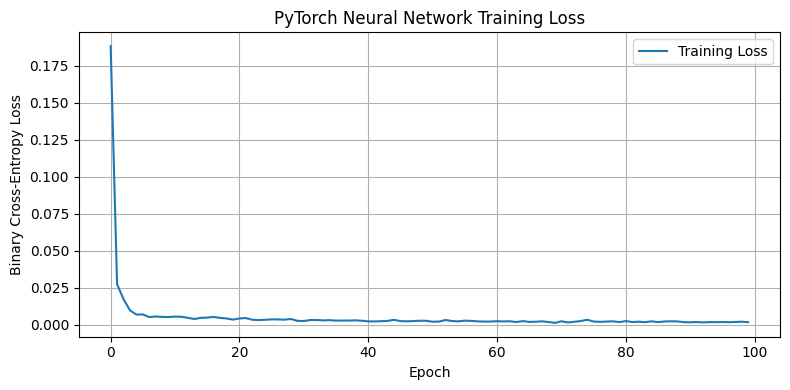

In [118]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.title('PyTorch Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [119]:
# Put model in eval mode
model.eval()
with torch.no_grad():
    full_X = torch.tensor(scaler.transform(features), dtype=torch.float32)
    mvp_scores = model(full_X).squeeze().numpy()

mvp_df["mvp_score"] = mvp_scores
predicted_mvps = mvp_df.loc[mvp_df.groupby("Season")["mvp_score"].idxmax()]
actual_mvps = mvp_df[mvp_df["is_MVP"] == 1]
correct_preds = (predicted_mvps["is_MVP"] == 1).sum()

print(f"Correct MVP predictions (PyTorch NN): {correct_preds} / {actual_mvps.shape[0]}")


Correct MVP predictions (PyTorch NN): 11 / 15
